# Perceptrón con el dataset Iris

**Análisis y procesamiento de Señales** - Bioingeniería - Fac. de Ingeniería - UNSTA - 2026

En esta notebook vamos a implementar un **perceptrón desde cero** (sin librerías de Deep Learning) y entrenarlo para clasificar flores del clásico *dataset Iris* usando la **Regla del Perceptrón** que vimos en clase.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_style("whitegrid")

## 1. El dataset Iris

El **Iris dataset** es uno de los datasets más clásicos del Machine Learning. Contiene 150 muestras de flores de tres especies:

- *Iris setosa*
- *Iris versicolor*
- *Iris virginica*

De cada flor se midieron 4 atributos en cm: largo y ancho del sépalo, y largo y ancho del pétalo.

In [2]:
iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Veamos cómo se distribuyen las tres especies usando el **largo y ancho del pétalo** — los dos atributos más discriminativos:

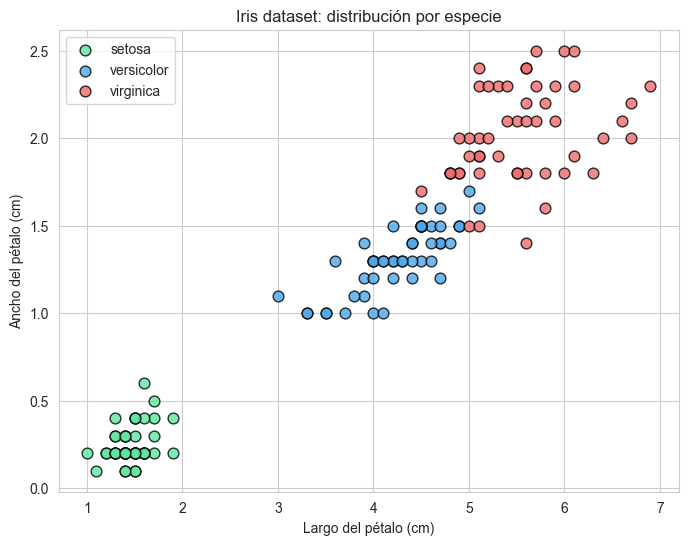

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = {"setosa": "#5ee6a0", "versicolor": "#4da6e8", "virginica": "#ef6c6c"}
for species, color in colors.items():
    subset = iris[iris["species"] == species]
    ax.scatter(subset["petal_length"], subset["petal_width"],
               label=species, color=color, s=60, edgecolor="black", alpha=0.8)
ax.set_xlabel("Largo del pétalo (cm)")
ax.set_ylabel("Ancho del pétalo (cm)")
ax.set_title("Iris dataset: distribución por especie")
ax.legend()
plt.show()

**Observación clave:** *setosa* está claramente separada del resto por una recta — es **linealmente separable**. En cambio, *versicolor* y *virginica* se superponen en la frontera y no se pueden separar perfectamente con una recta.

Como vamos a ver, esto va a determinar si la **Regla del Perceptrón** converge o no.

## 2. Reducimos el problema a clasificación binaria

El perceptrón que armamos en clase tiene **una sola salida binaria** ($y \in \{0, 1\}$), así que sólo distingue entre **dos clases**. Empecemos por el caso fácil: *setosa* vs *versicolor*.

In [4]:
mask = iris["species"].isin(["setosa", "versicolor"])
data = iris[mask].reset_index(drop=True)

X = data[["petal_length", "petal_width"]].values
d = (data["species"] == "versicolor").astype(int).values

print(f"Cantidad de muestras: {len(X)}")
print(f"X.shape: {X.shape}, d.shape: {d.shape}")
print(f"Clases: 0 = setosa, 1 = versicolor")

Cantidad de muestras: 100
X.shape: (100, 2), d.shape: (100,)
Clases: 0 = setosa, 1 = versicolor


## 3. Implementación del perceptrón

Repasemos lo que vimos en clase.

**Salida del perceptrón** (slide 22): la parte lineal calcula

$$z = \sum_{i=1}^{n} w_i x_i + b$$

y la salida pasa por la **función de activación escalón**:

$$y = f(z) = \begin{cases} 1 & \text{si } z \geq 0 \\ 0 & \text{si } z < 0 \end{cases}$$

**Truco del bias** (slide 23): para simplificar la notación, absorbemos el *bias* como un peso extra $w_{n+1}$ asociado a una entrada constante $x_{n+1} = 1$. Así trabajamos con un único vector $\vec{W}$ de tamaño $n+1$.

**Regla del Perceptrón** (slide 39):
- Si la salida $y$ es **correcta** ($y = d$), los pesos no cambian.
- Si es **incorrecta**, cada peso se ajusta proporcionalmente al error:

$$\Delta w_i = \eta \cdot (d - y) \cdot x_i$$

Inicializamos los pesos al azar entre $-1$ y $1$ (slide 36).

In [5]:
class Perceptron:
    def __init__(self, n_inputs, eta=0.1, max_epochs=100, seed=42):
        rng = np.random.default_rng(seed)
        # n_inputs + 1 para absorber el bias como un peso más
        self.W = rng.uniform(-1, 1, size=n_inputs + 1)
        self.eta = eta
        self.max_epochs = max_epochs
        self.history = {"errors": [], "weights": [self.W.copy()]}

    def _add_bias(self, X):
        # Agrega una columna de 1s para que x_{n+1} = 1
        return np.hstack([X, np.ones((X.shape[0], 1))])

    def _step(self, z):
        return (z >= 0).astype(int)

    def predict(self, X):
        Xb = self._add_bias(X)
        return self._step(Xb @ self.W)

    def fit(self, X, d):
        Xb = self._add_bias(X)
        n_samples = len(X)
        rng = np.random.default_rng(0)

        for epoch in range(self.max_epochs):
            errors = 0
            # Mezclamos el orden de las muestras en cada época
            for i in rng.permutation(n_samples):
                x_i, d_i = Xb[i], d[i]
                y_i = 1 if x_i @ self.W >= 0 else 0
                if y_i != d_i:
                    # Regla del Perceptrón: Δw = η · (d - y) · x
                    self.W += self.eta * (d_i - y_i) * x_i
                    errors += 1

            self.history["errors"].append(errors)
            self.history["weights"].append(self.W.copy())

            if errors == 0:
                print(f"Convergió en la época {epoch + 1}")
                return

        print(f"No convergió tras {self.max_epochs} épocas (errores finales: {errors})")

## 4. Entrenamiento

Entrenamos el perceptrón con $\eta = 0.1$ y un máximo de 50 épocas:

In [6]:
perceptron = Perceptron(n_inputs=2, eta=0.002, max_epochs=50)
perceptron.fit(X, d)

print(f"\nPesos finales: w_1 = {perceptron.W[0]:.3f}, w_2 = {perceptron.W[1]:.3f}, b = {perceptron.W[2]:.3f}")

Convergió en la época 29

Pesos finales: w_1 = 0.038, w_2 = -0.039, b = -0.069


Veamos cómo evolucionó el número de errores por época:

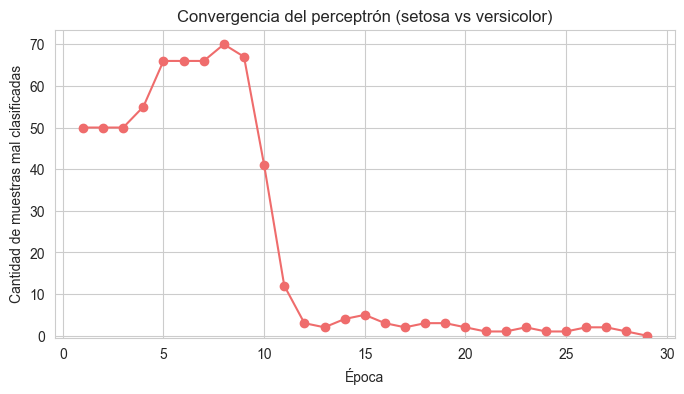

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
errors = perceptron.history["errors"]
ax.plot(range(1, len(errors) + 1), errors, marker="o", color="#ef6c6c")
ax.set_xlabel("Época")
ax.set_ylabel("Cantidad de muestras mal clasificadas")
ax.set_title("Convergencia del perceptrón (setosa vs versicolor)")
ax.set_ylim(bottom=-0.5)
plt.show()

## 5. Frontera de decisión

Como vimos en clase (slides 41–44), un perceptrón con dos entradas define una **recta** en el plano de entrada:

$$w_1 x_1 + w_2 x_2 + b = 0 \quad\Rightarrow\quad x_2 = -\frac{w_1}{w_2} x_1 - \frac{b}{w_2}$$

Esta recta es la **frontera de decisión** que separa las dos clases:

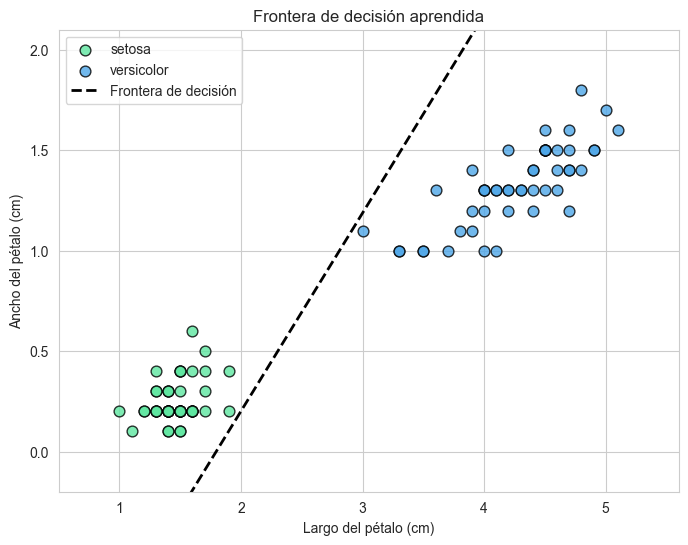

In [8]:
def plot_boundary(perceptron, X, d, ax, class_names):
    for cls, color in zip([0, 1], ["#5ee6a0", "#4da6e8"]):
        mask = d == cls
        ax.scatter(X[mask, 0], X[mask, 1], label=class_names[cls],
                   color=color, s=60, edgecolor="black", alpha=0.8)

    w1, w2, b = perceptron.W
    x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x1_range = np.array([x1_min, x1_max])
    if abs(w2) > 1e-9:
        x2_line = -(w1 * x1_range + b) / w2
        ax.plot(x1_range, x2_line, "k--", linewidth=2, label="Frontera de decisión")

    ax.set_xlabel("Largo del pétalo (cm)")
    ax.set_ylabel("Ancho del pétalo (cm)")
    ax.set_xlim(x1_min, x1_max)
    ax.set_ylim(X[:, 1].min() - 0.3, X[:, 1].max() + 0.3)
    ax.legend()


fig, ax = plt.subplots(figsize=(8, 6))
plot_boundary(perceptron, X, d, ax, {0: "setosa", 1: "versicolor"})
ax.set_title("Frontera de decisión aprendida")
plt.show()

La recta separa perfectamente las dos clases — el perceptrón aprendió a distinguir *setosa* de *versicolor*.

Verificamos también la precisión en el conjunto de entrenamiento:

In [9]:
y_pred = perceptron.predict(X)
accuracy = (y_pred == d).mean()
print(f"Precisión en entrenamiento: {accuracy * 100:.1f}%")

Precisión en entrenamiento: 100.0%


## 6. Animación del entrenamiento

Veamos en movimiento cómo el perceptrón **mueve la frontera de decisión** y cómo va **bajando el error** a lo largo de las épocas. La animación está sincronizada: la curva de la izquierda muestra el error por época y el panel derecho la frontera de decisión correspondiente a esa época.

In [10]:
from matplotlib import animation, rc

rc("animation", html="html5")

# Tomamos un snapshot de los pesos al final de cada época (ya guardados en perceptron.history["weights"])
weights_history = perceptron.history["weights"]
errors_history = perceptron.history["errors"]
n_epochs_total = len(errors_history)

# Sub-muestreamos si hay muchas épocas, para mantener la animación corta
stride = max(1, len(weights_history) // 180)
frame_indices = list(range(0, len(weights_history), stride))
n_frames = len(frame_indices)

# Elementos fijos
x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
x2_min, x2_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
err_max = max(errors_history) * 1.1 if errors_history else 1


# Recortamos la recta w1·x1 + w2·x2 + b = 0 al área visible
def line_in_box(w1, w2, b):
    pts = []
    if abs(w2) > 1e-9:
        for x1 in (x1_min, x1_max):
            x2 = -(w1 * x1 + b) / w2
            if x2_min - 1e-6 <= x2 <= x2_max + 1e-6:
                pts.append((x1, x2))
    if abs(w1) > 1e-9:
        for x2 in (x2_min, x2_max):
            x1 = -(w2 * x2 + b) / w1
            if x1_min - 1e-6 <= x1 <= x1_max + 1e-6:
                pts.append((x1, x2))
    return pts[:2]


fig, (ax_err, ax_bnd) = plt.subplots(1, 2, figsize=(13, 5))


def update(i):
    epoch_idx = frame_indices[i]
    W = weights_history[epoch_idx]

    # Errores hasta esta época
    ax_err.clear()
    if epoch_idx > 0:
        ax_err.plot(range(1, epoch_idx + 1), errors_history[:epoch_idx],
                    color="#ef6c6c", linewidth=2, marker="o", markersize=4)
    ax_err.set_xlim(0, n_epochs_total)
    ax_err.set_ylim(-1, err_max)
    ax_err.set_xlabel("Época")
    ax_err.set_ylabel("Errores de clasificación")
    ax_err.set_title("Evolución del error")
    ax_err.grid(True, alpha=0.3)

    # Frontera de decisión en esta época
    ax_bnd.clear()
    for cls, color, name in zip([0, 1], ["#5ee6a0", "#4da6e8"], ["setosa", "versicolor"]):
        mask = d == cls
        ax_bnd.scatter(X[mask, 0], X[mask, 1], color=color, s=50,
                       edgecolor="black", alpha=0.8, label=name)
    pts = line_in_box(*W)
    if len(pts) == 2:
        (a_x, a_y), (b_x, b_y) = pts
        ax_bnd.plot([a_x, b_x], [a_y, b_y], "k--", linewidth=2)
    ax_bnd.set_xlim(x1_min, x1_max)
    ax_bnd.set_ylim(x2_min, x2_max)
    ax_bnd.set_xlabel("Largo del pétalo (cm)")
    ax_bnd.set_ylabel("Ancho del pétalo (cm)")
    ax_bnd.set_title(f"Frontera de decisión — época {epoch_idx}")
    ax_bnd.legend(loc="upper left")
    ax_bnd.grid(True, alpha=0.3)

    plt.tight_layout()
    return ax_err, ax_bnd


anim = animation.FuncAnimation(fig, update, frames=n_frames, interval=500)
plt.close(fig)
anim

<Figure size 640x480 with 0 Axes>

Mirando la animación se ve algo interesante de la **Regla del Perceptrón** que ya discutimos en clase:

- La curva del error **no baja monótonamente**: hay épocas donde el error sube antes de volver a bajar.
- La frontera de decisión se mueve, y a veces "pasa de largo" puntos que ya estaba clasificando bien — los rompe momentáneamente, después los recupera.

> Esto es porque la Regla del Perceptrón **no es descenso por gradiente**: actualiza los pesos para corregir muestras individuales mal clasificadas, sin pensar en el efecto global. En la próxima clase vamos a ver cómo la **Regla Delta** corrige justamente eso.

## 7. ¿Y si los datos no son linealmente separables?

Probemos ahora con *versicolor* vs *virginica*, que se superponen en el plano:

In [11]:
mask2 = iris["species"].isin(["versicolor", "virginica"])
data2 = iris[mask2].reset_index(drop=True)

X2 = data2[["petal_length", "petal_width"]].values
d2 = (data2["species"] == "virginica").astype(int).values

perceptron2 = Perceptron(n_inputs=2, eta=0.1, max_epochs=500)
perceptron2.fit(X2, d2)

No convergió tras 500 épocas (errores finales: 11)


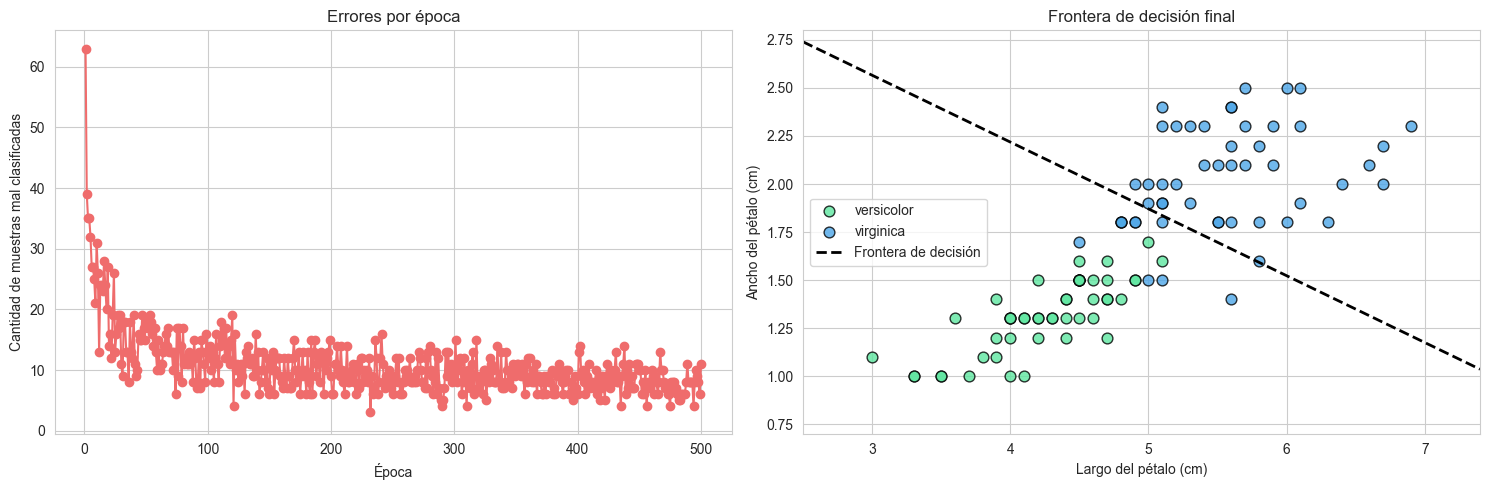

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

errors2 = perceptron2.history["errors"]
axes[0].plot(range(1, len(errors2) + 1), errors2, marker="o", color="#ef6c6c")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Cantidad de muestras mal clasificadas")
axes[0].set_title("Errores por época")
axes[0].set_ylim(bottom=-0.5)

plot_boundary(perceptron2, X2, d2, axes[1], {0: "versicolor", 1: "virginica"})
axes[1].set_title("Frontera de decisión final")

plt.tight_layout()
plt.show()

Como predice la teoría (slide 45):

- El error **nunca llega a cero** — siempre hay muestras mal clasificadas.
- El bucle de entrenamiento **nunca converge** (cortamos por `max_epochs`).
- La frontera de decisión **oscila** entre épocas tratando de "atrapar" muestras que no son linealmente separables.

> Esto motiva exactamente el desarrollo de la **Regla Delta** y el **descenso por gradiente** que vamos a ver en la próxima clase: en lugar de exigir error cero, vamos a *minimizar* una función de costo continua. Eso permite entrenar también con datos no separables y con activaciones derivables.

## Conclusiones

- Implementamos un perceptrón **desde cero** usando solamente `numpy`.
- Entrenamos con la **Regla del Perceptrón** y verificamos que **converge** cuando los datos son linealmente separables (*setosa* vs *versicolor*).
- Verificamos también su **limitación principal**: con datos no linealmente separables (*versicolor* vs *virginica*), el algoritmo **no converge**.
- En la próxima clase vamos a ver cómo superar esta limitación entrenando por **minimización del error**.